# Spectrum Class -- Component Adding & Composition

This notebook demonstrates how to build up a model spectrum by adding individual
molecular intensity components to a `Spectrum` object.  It covers:

1. **Creating a Spectrum** -- Wavelength grid setup and resolution
2. **Adding intensity components** -- `add_intensity()` with area scaling
3. **Multi-component composition** -- Flux additivity across molecules
4. **Optical depth profiles** -- `tau_profile` and per-component breakdown
5. **Flux vs optical depth** -- Comparing flux and tau
6. **Distance scaling** -- Flux proportional to $1/d^2$, tau is distance-independent
7. **Resampling** -- `resample_to()` for observer-frame grids
8. **Cache behaviour** -- Lazy evaluation and invalidation

In [19]:
%matplotlib inline
# %matplotlib widget   # for interactive plots with ipympl

import numpy as np
import matplotlib.pyplot as plt

from iSLAT.Modules.DataTypes import Spectrum, Intensity, MoleculeLineList
from iSLAT.Modules.FileHandling import hitran_data_folder_path

print("Imports successful!")

Imports successful!


In [20]:
# --- Load two well-separated molecules ---
data_dir = hitran_data_folder_path
wavelength_range = (4.5, 20.0)

# CO: lines clustered around 4.5-5.2 um
co_lines = MoleculeLineList(
    molecule_id="CO",
    filename=str(data_dir / "data_Hitran_CO.par"),
    wavelength_range=wavelength_range,
)

# H2O: lines across the full MIR range
h2o_lines = MoleculeLineList(
    molecule_id="H2O",
    filename=str(data_dir / "data_Hitran_H2O.par"),
    wavelength_range=wavelength_range,
)

print(f"CO:  {len(co_lines)} lines in {wavelength_range} um")
print(f"H2O: {len(h2o_lines)} lines in {wavelength_range} um")

CO:  230 lines in (4.5, 20.0) um
H2O: 13738 lines in (4.5, 20.0) um


In [21]:
# --- Calculate intensities for both molecules ---
co_intensity = Intensity(co_lines)
co_intensity.calc_intensity(t_kin=1000.0, n_mol=1e18, dv=2.0)

h2o_intensity = Intensity(h2o_lines)
h2o_intensity.calc_intensity(t_kin=850.0, n_mol=1e18, dv=2.0)

print(f"CO  -- {co_intensity.intensity.shape[0]} lines, max tau = {co_intensity.tau.max():.3f}")
print(f"H2O -- {h2o_intensity.intensity.shape[0]} lines, max tau = {h2o_intensity.tau.max():.3f}")

CO  -- 230 lines, max tau = 14.480
H2O -- 13738 lines, max tau = 56.810


## 1. Creating a Spectrum

A `Spectrum` defines a wavelength grid with a given spectral resolution **R** and pixel spacing **dlambda**.
The `distance` parameter sets the observer distance in parsecs (used for flux scaling).

```python
Spectrum(lam_min, lam_max, dlambda, R, distance, R_func=None)
```

In [22]:
# Create an empty spectrum covering 4.5-20 um
spec = Spectrum(
    lam_min=4.5,
    lam_max=20.0,
    dlambda=0.001,   # pixel spacing in microns
    R=3000.0,        # spectral resolving power
    distance=160.0,  # distance in parsecs
)

print(f"Grid points:      {len(spec.lamgrid)}")
print(f"Wavelength range: {spec.lamgrid.min():.2f} - {spec.lamgrid.max():.2f} um")
print(f"Components:       {len(spec.components)}")
print(f"Flux (empty):     max = {spec.flux.max():.1e}")

Grid points:      15501
Wavelength range: 4.50 - 20.00 um
Components:       0
Flux (empty):     max = 0.0e+00


## 2. Adding Intensity Components

`add_intensity(intensity, dA)` convolves the per-line intensities and taus
with a Gaussian kernel at the spectrum's resolving power and adds them to
the internal accumulation arrays.

- **intensity** -- a calculated `Intensity` object
- **dA** -- emitting area in AU^2  (flux scales linearly with area)

In [23]:
# Add CO with an emitting area of 0.5 AU^2
spec.add_intensity(co_intensity, dA=0.5)

print(f"Components after adding CO: {len(spec.components)}")
print(f"Component info: {spec.components[0]}")
print(f"Max flux: {spec.flux.max():.4e}")

Components after adding CO: 1
Component info: {'name': 'CO', 'fname': 'C:\\Users\\drago\\OneDrive\\Documents\\banzatti\\NewiSLAT\\iSLATTests\\iSLAT\\DATAFILES\\HITRANdata\\data_Hitran_CO.par', 't_kin': 1000.0, 'n_mol': 1e+18, 'dv': 2.0, 'tau': array([1.12956789e-02, 1.51081937e-02, 2.00961374e-02, 2.65829296e-02,
       3.49959038e-02, 4.57776124e-02, 1.55912786e-02, 5.95454317e-02,
       1.96689858e-02, 7.70178401e-02, 2.46807564e-02, 9.91300171e-02,
       3.07793696e-02, 1.26767364e-01, 3.81629680e-02, 1.61306126e-01,
       4.70602397e-02, 2.03921988e-01, 5.76702146e-02, 2.56500763e-01,
       7.02821920e-02, 3.20524508e-01, 1.48620716e-02, 8.51124220e-02,
       1.73250054e-02, 3.98485963e-01, 1.02494427e-01, 2.00749870e-02,
       4.92141045e-01, 1.22683069e-01, 2.31148378e-02, 6.04658641e-01,
       1.45957707e-01, 2.64451615e-02, 1.72585905e-01, 7.37953433e-01,
       3.00598809e-02, 2.02813399e-01, 8.95888085e-01, 3.39450127e-02,
       2.36851266e-01, 1.08106801e+00, 3.80866

In [24]:
# Add H2O with a different area
spec.add_intensity(h2o_intensity, dA=0.3)

print(f"Components: {len(spec.components)}")
for i, comp in enumerate(spec.components):
    print(f"  [{i}] {comp['name']}: T={comp['t_kin']} K, "
          f"N={comp['n_mol']:.1e}, area={comp['area']} AU^2")

Components: 2
  [0] CO: T=1000.0 K, N=1.0e+18, area=0.5 AU^2
  [1] H2O: T=850.0 K, N=1.0e+18, area=0.3 AU^2


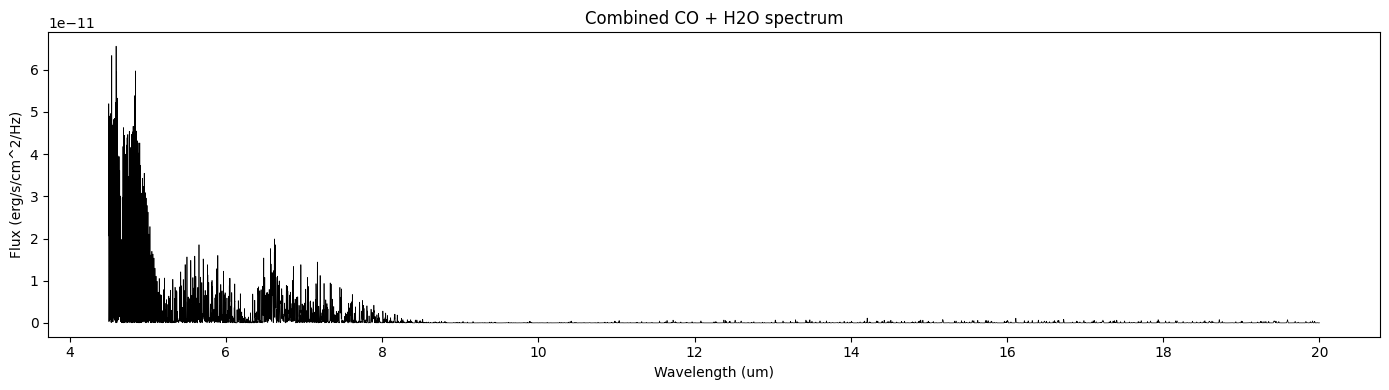

In [25]:
# Plot the combined spectrum
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(spec.lamgrid, spec.flux, color='black', lw=0.5)
ax.set_xlabel('Wavelength (um)')
ax.set_ylabel('Flux (erg/s/cm^2/Hz)')
ax.set_title('Combined CO + H2O spectrum')
plt.tight_layout()
plt.show()

### Area scaling

Doubling the emitting area doubles the flux, since `add_intensity` multiplies
intensities by `dA` before convolution.

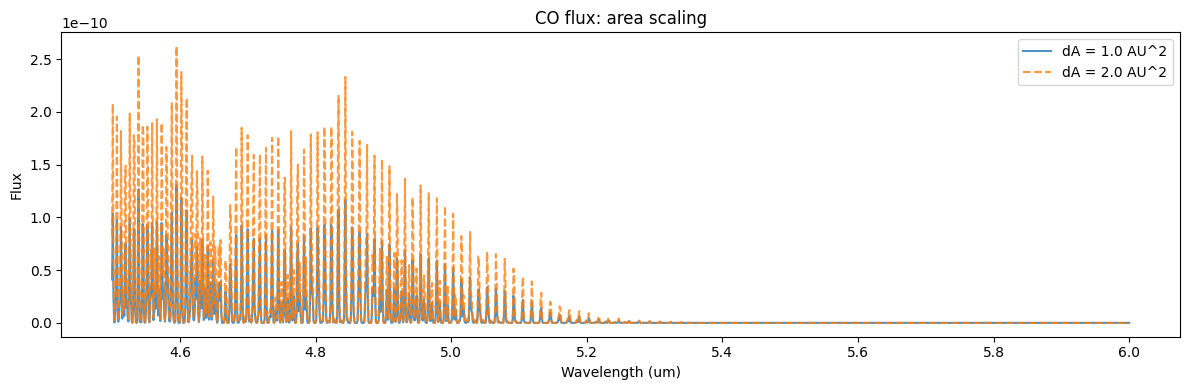

Flux ratio (2x / 1x): 2.000000 (expected 2.0)


In [26]:
# Demonstrate area scaling
spec_1x = Spectrum(lam_min=4.5, lam_max=6.0, dlambda=0.001, R=3000.0, distance=160.0)
spec_1x.add_intensity(co_intensity, dA=1.0)

spec_2x = Spectrum(lam_min=4.5, lam_max=6.0, dlambda=0.001, R=3000.0, distance=160.0)
spec_2x.add_intensity(co_intensity, dA=2.0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(spec_1x.lamgrid, spec_1x.flux, label='dA = 1.0 AU^2', alpha=0.8)
ax.plot(spec_2x.lamgrid, spec_2x.flux, label='dA = 2.0 AU^2', alpha=0.8, ls='--')
ax.set_xlabel('Wavelength (um)')
ax.set_ylabel('Flux')
ax.set_title('CO flux: area scaling')
ax.legend()
plt.tight_layout()
plt.show()

# Verify: ratio should be exactly 2
mask = spec_1x.flux > 0
ratio = spec_2x.flux[mask] / spec_1x.flux[mask]
print(f"Flux ratio (2x / 1x): {ratio.mean():.6f} (expected 2.0)")

## 3. Multi-Component Flux Additivity

When molecules have well-separated lines, the combined flux equals
the sum of individually convolved spectra.

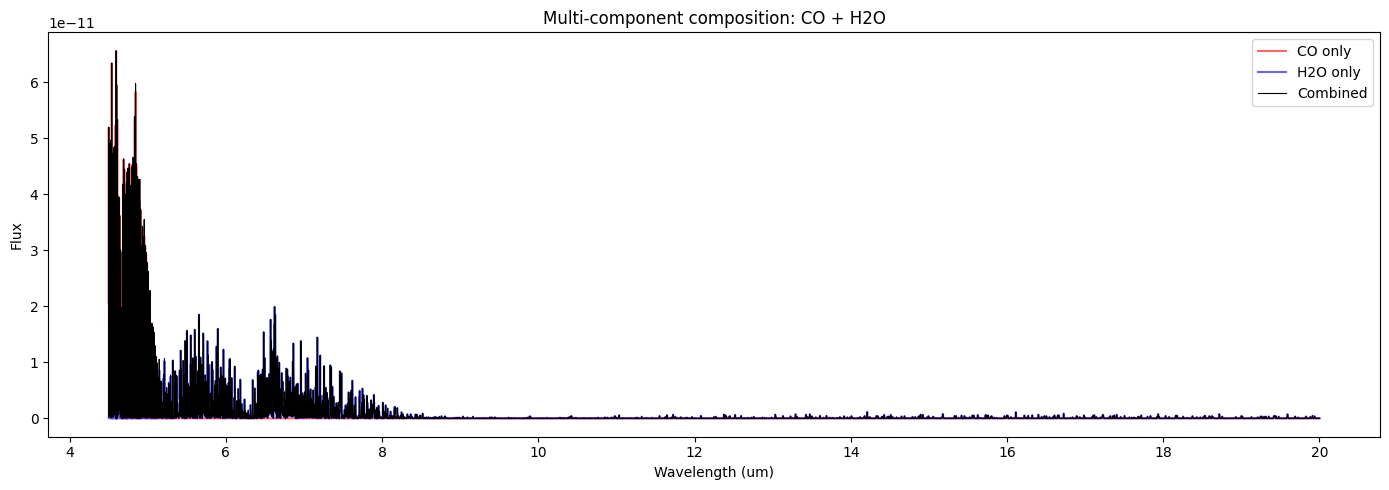

Max absolute difference (combined vs sum): 2.58e-26


In [27]:
# Combined spectrum (both molecules)
spec_both = Spectrum(lam_min=4.5, lam_max=20.0, dlambda=0.001, R=3000.0, distance=160.0)
spec_both.add_intensity(co_intensity, dA=0.5)
spec_both.add_intensity(h2o_intensity, dA=0.3)

# Individual spectra
spec_co = Spectrum(lam_min=4.5, lam_max=20.0, dlambda=0.001, R=3000.0, distance=160.0)
spec_co.add_intensity(co_intensity, dA=0.5)

spec_h2o = Spectrum(lam_min=4.5, lam_max=20.0, dlambda=0.001, R=3000.0, distance=160.0)
spec_h2o.add_intensity(h2o_intensity, dA=0.3)

# Plot comparison
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(spec_co.lamgrid, spec_co.flux, label='CO only', color='red', alpha=0.6)
ax.plot(spec_h2o.lamgrid, spec_h2o.flux, label='H2O only', color='blue', alpha=0.6)
ax.plot(spec_both.lamgrid, spec_both.flux, label='Combined', color='black', lw=0.8)
ax.set_xlabel('Wavelength (um)')
ax.set_ylabel('Flux')
ax.set_title('Multi-component composition: CO + H2O')
ax.legend()
plt.tight_layout()
plt.show()

# Verify additivity
summed = spec_co.flux + spec_h2o.flux
max_diff = np.max(np.abs(spec_both.flux - summed))
print(f"Max absolute difference (combined vs sum): {max_diff:.2e}")

## 4. Optical Depth Profiles

The `tau_profile` property returns the convolved optical depth on the wavelength grid.
Unlike flux, **tau is not scaled by emitting area or distance** -- it is an intrinsic
column property.

Use `_convol_tau_per_component()` to get the per-molecule breakdown.

Tau profile shape: (15501,)
Peak tau: 10646.6636


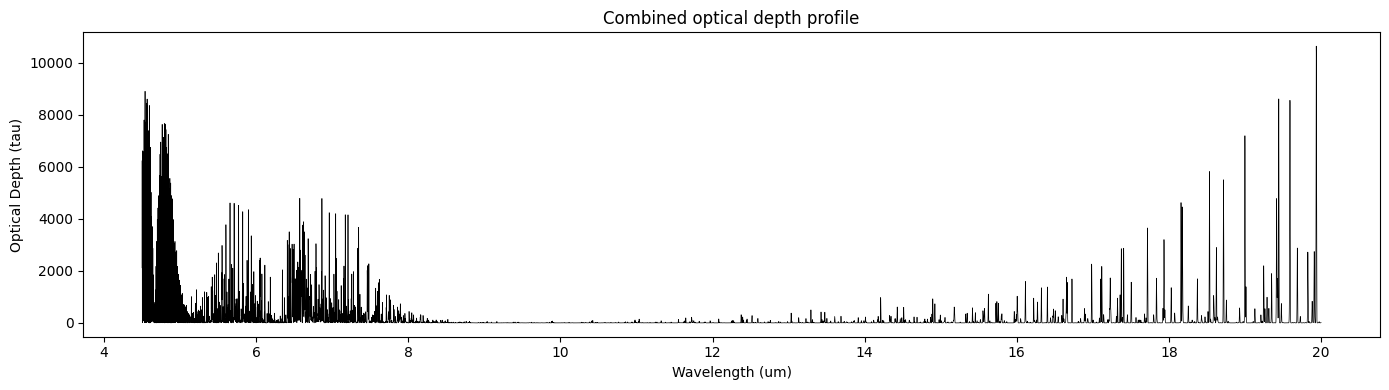

In [28]:
# Total tau profile
tau_total = spec_both.tau_profile

print(f"Tau profile shape: {tau_total.shape}")
print(f"Peak tau: {tau_total.max():.4f}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(spec_both.lamgrid, tau_total, color='black', lw=0.5)
ax.set_xlabel('Wavelength (um)')
ax.set_ylabel('Optical Depth (tau)')
ax.set_title('Combined optical depth profile')
plt.tight_layout()
plt.show()

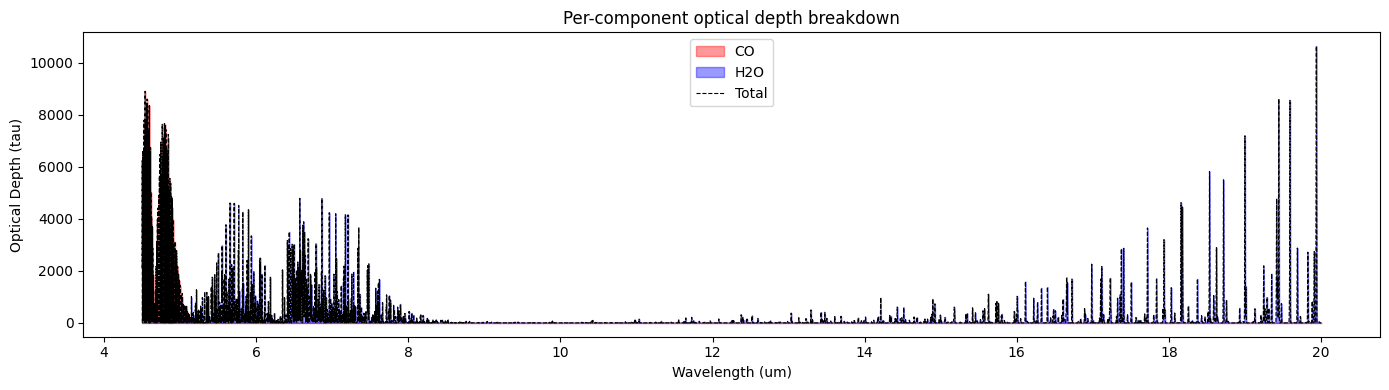

Max difference (total vs sum of components): 2.73e-12


In [29]:
# Per-component breakdown
per_comp = spec_both._convol_tau_per_component()

fig, ax = plt.subplots(figsize=(14, 4))
colors = {'CO': 'red', 'H2O': 'blue'}

for comp in per_comp:
    color = colors.get(comp['name'], 'gray')
    ax.fill_between(spec_both.lamgrid, comp['tau_profile'],
                    alpha=0.4, color=color, label=comp['name'])

ax.plot(spec_both.lamgrid, tau_total, color='black', lw=0.8,
        ls='--', label='Total')
ax.set_xlabel('Wavelength (um)')
ax.set_ylabel('Optical Depth (tau)')
ax.set_title('Per-component optical depth breakdown')
ax.legend()
plt.tight_layout()
plt.show()

# Verify: per-component sum equals total
summed_tau = sum(c['tau_profile'] for c in per_comp)
max_diff = np.max(np.abs(tau_total - summed_tau))
print(f"Max difference (total vs sum of components): {max_diff:.2e}")

## 5. Flux vs Optical Depth

Flux and tau have very different profiles.  Flux is area- and distance-scaled;
tau is an intrinsic column property.  Here we compare them side by side.

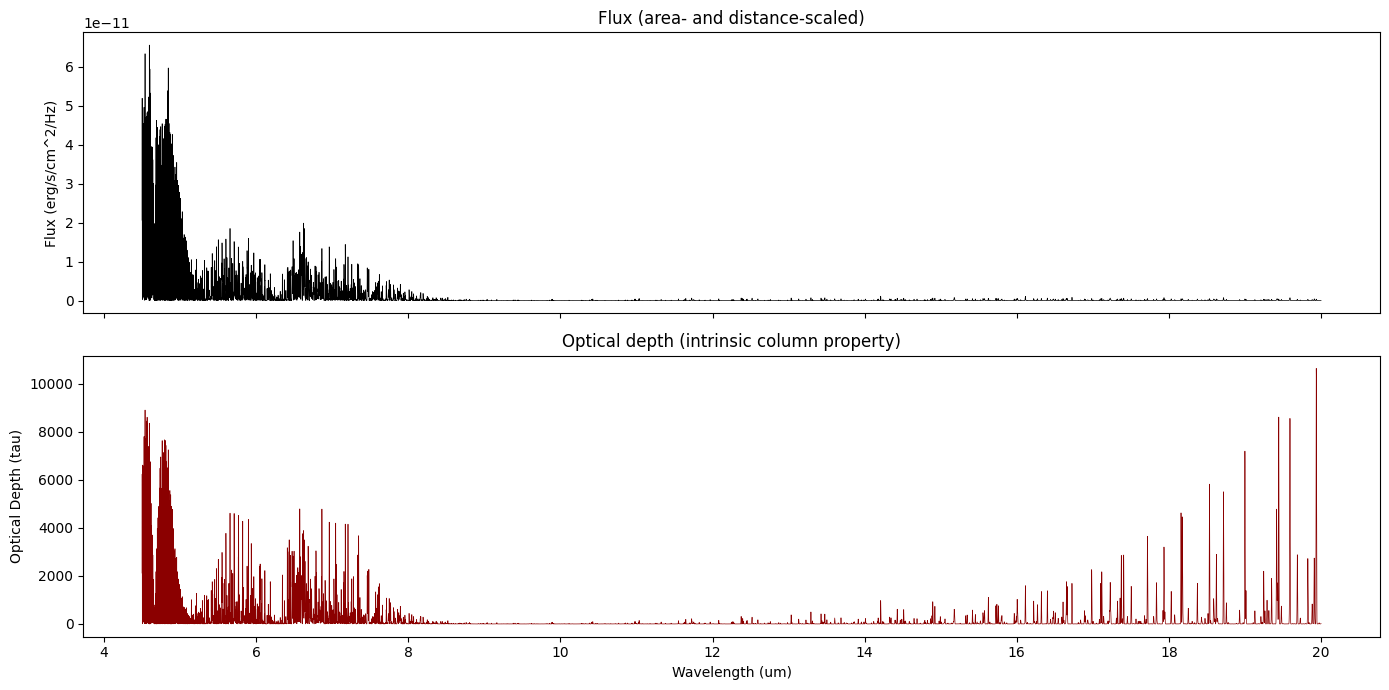

In [30]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(spec_both.lamgrid, spec_both.flux, color='black', lw=0.5)
ax1.set_ylabel('Flux (erg/s/cm^2/Hz)')
ax1.set_title('Flux (area- and distance-scaled)')

ax2.plot(spec_both.lamgrid, spec_both.tau_profile, color='darkred', lw=0.5)
ax2.set_xlabel('Wavelength (um)')
ax2.set_ylabel('Optical Depth (tau)')
ax2.set_title('Optical depth (intrinsic column property)')

plt.tight_layout()
plt.show()

## 6. Distance Scaling

Flux scales as 1/d^2 (inverse-square law).  Optical depth is independent of distance.

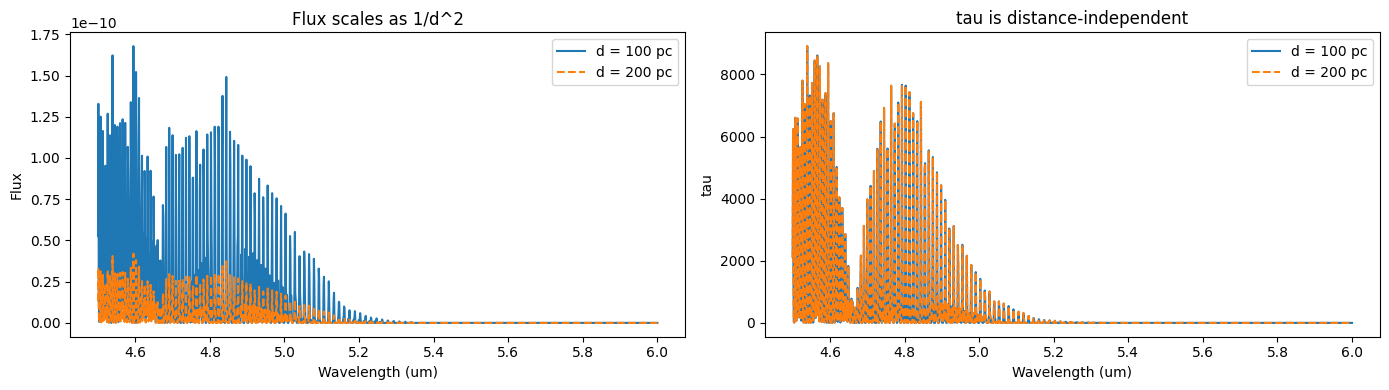

Flux ratio (near/far): 4.00  (expected 4.0)
Tau difference: 0.00e+00  (expected ~0)


In [31]:
# Two spectra at different distances
spec_near = Spectrum(lam_min=4.5, lam_max=6.0, dlambda=0.001, R=3000.0, distance=100.0)
spec_near.add_intensity(co_intensity, dA=0.5)

spec_far = Spectrum(lam_min=4.5, lam_max=6.0, dlambda=0.001, R=3000.0, distance=200.0)
spec_far.add_intensity(co_intensity, dA=0.5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Flux comparison
ax1.plot(spec_near.lamgrid, spec_near.flux, label='d = 100 pc')
ax1.plot(spec_far.lamgrid, spec_far.flux, label='d = 200 pc', ls='--')
ax1.set_xlabel('Wavelength (um)')
ax1.set_ylabel('Flux')
ax1.set_title('Flux scales as 1/d^2')
ax1.legend()

# Tau comparison
ax2.plot(spec_near.lamgrid, spec_near.tau_profile, label='d = 100 pc')
ax2.plot(spec_far.lamgrid, spec_far.tau_profile, label='d = 200 pc', ls='--')
ax2.set_xlabel('Wavelength (um)')
ax2.set_ylabel('tau')
ax2.set_title('tau is distance-independent')
ax2.legend()

plt.tight_layout()
plt.show()

# Verify
mask = spec_near.flux > 0
flux_ratio = spec_near.flux[mask] / spec_far.flux[mask]
print(f"Flux ratio (near/far): {flux_ratio.mean():.2f}  (expected {(200/100)**2:.1f})")
print(f"Tau difference: {np.max(np.abs(spec_near.tau_profile - spec_far.tau_profile)):.2e}  (expected ~0)")

## 7. Resampling

`resample_to(target_wavelengths)` resamples the model flux onto an arbitrary
wavelength grid using flux-conserving spectral resampling.  Supports
RV shifts and unit conversion.

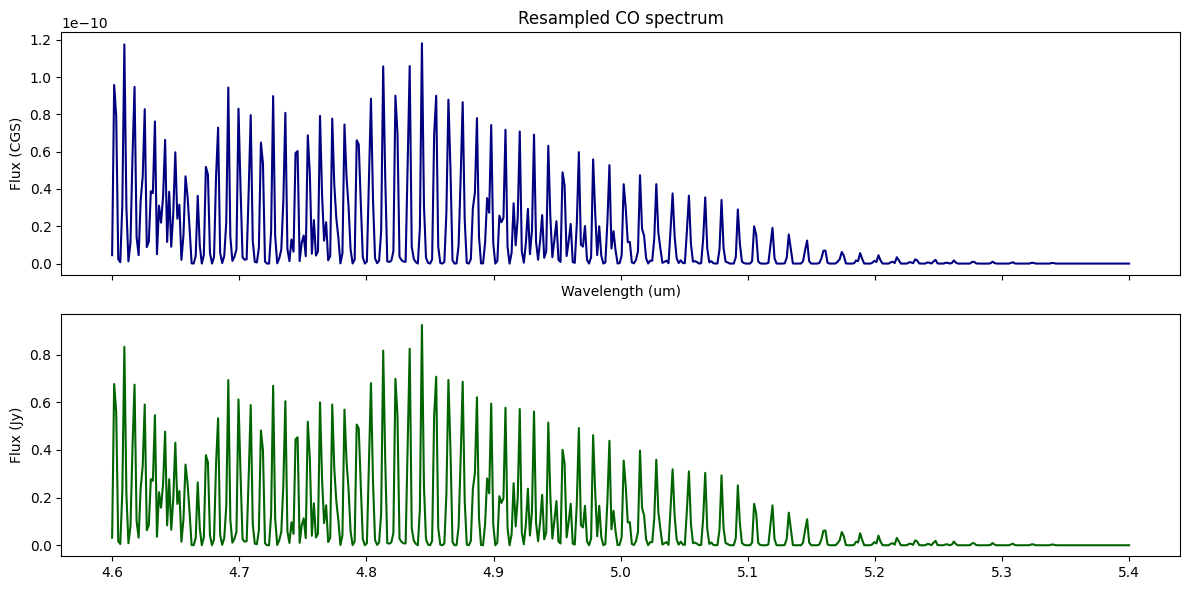

Original grid points: 1501
Resampled grid points: 500


In [32]:
# Resample to a coarse observer grid
obs_grid = np.linspace(4.6, 5.4, 500)

resampled_cgs = spec_near.resample_to(obs_grid, unit='cgs')
resampled_jy  = spec_near.resample_to(obs_grid, unit='jy')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(obs_grid, resampled_cgs, color='navy')
ax1.set_ylabel('Flux (CGS)')
ax1.set_title('Resampled CO spectrum')

ax2.plot(obs_grid, resampled_jy, color='darkgreen')
ax1.set_xlabel('Wavelength (um)')
ax2.set_ylabel('Flux (Jy)')

plt.tight_layout()
plt.show()

print(f"Original grid points: {len(spec_near.lamgrid)}")
print(f"Resampled grid points: {len(obs_grid)}")

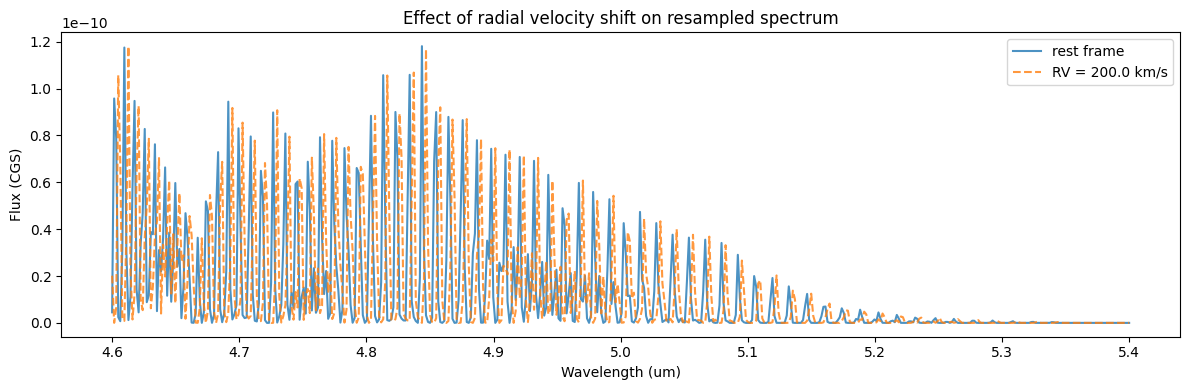

In [33]:
# Resampling with RV shift
rv_shift = 200.0  # km/s

flux_rest = spec_near.resample_to(obs_grid, rv_shift=0.0, unit='cgs')
flux_rv   = spec_near.resample_to(obs_grid, rv_shift=rv_shift, unit='cgs')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(obs_grid, flux_rest, label='rest frame', alpha=0.8)
ax.plot(obs_grid, flux_rv, label=f'RV = {rv_shift} km/s', alpha=0.8, ls='--')
ax.set_xlabel('Wavelength (um)')
ax.set_ylabel('Flux (CGS)')
ax.set_title('Effect of radial velocity shift on resampled spectrum')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Cache Behaviour

The `Spectrum` uses lazy evaluation: flux and tau are computed only when first
accessed, then cached.  The cache is automatically invalidated when:
- A new intensity component is added
- The wavelength range is changed
- The R_func is changed
- `reset()` is called

In [34]:
# Demonstrate cache behaviour
spec_cache = Spectrum(lam_min=4.5, lam_max=6.0, dlambda=0.001, R=3000.0, distance=160.0)
spec_cache.add_intensity(co_intensity, dA=0.5)

# Flux is not yet computed
print(f"Flux valid before access: {spec_cache._flux_valid}")
print(f"Tau valid before access:  {spec_cache._tau_profile_valid}")

# Access flux -- triggers computation
_ = spec_cache.flux
print(f"\nFlux valid after access:  {spec_cache._flux_valid}")
print(f"Tau valid (still lazy):   {spec_cache._tau_profile_valid}")

# Access tau -- computed independently
_ = spec_cache.tau_profile
print(f"\nTau valid after access:   {spec_cache._tau_profile_valid}")

# Add another component -- invalidates both caches
spec_cache.add_intensity(h2o_intensity, dA=0.3)
print(f"\nAfter adding H2O:")
print(f"  Flux valid: {spec_cache._flux_valid}")
print(f"  Tau valid:  {spec_cache._tau_profile_valid}")

Flux valid before access: False
Tau valid before access:  False

Flux valid after access:  True
Tau valid (still lazy):   False

Tau valid after access:   True

After adding H2O:
  Flux valid: False
  Tau valid:  False


In [35]:
# Cache stats
stats = spec_cache.get_cache_stats()
for key, val in stats.items():
    print(f"  {key}: {val}")

  hits: 0
  misses: 1
  invalidations: 2


In [36]:
# reset() clears all components and caches
spec_cache.reset()
print(f"After reset():")
print(f"  Components: {len(spec_cache.components)}")
print(f"  Max flux:   {spec_cache.flux.max():.1e}")

After reset():
  Components: 0
  Max flux:   0.0e+00


## Summary

| Feature | Property / Method | Notes |
|---|---|---|
| Add component | `add_intensity(intensity, dA)` | Flux proportional to dA |
| Convolved flux | `spec.flux` | Distance-scaled, lazy |
| Convolved tau | `spec.tau_profile` | Intrinsic, lazy |
| Per-component tau | `spec._convol_tau_per_component()` | List of dicts |
| Flux in Jy | `spec.flux_jy` | CGS -> Jy conversion |
| Resample | `spec.resample_to(grid, unit, rv_shift)` | Flux-conserving |
| Cache stats | `spec.get_cache_stats()` | Hit/miss/invalidation |
| Clear all | `spec.reset()` | Preserves grid & R |